Validity testing script for Spynal circular (angular) statistics functions.

Tests how various statistic values vary with n (trials), SNR, etc. and plots results.

In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

from spynal.utils import iarange
from spynal.tests.validity_test_circstats import test_circ_diff, test_circ_mean, test_circ_spread, \
                                    test_rayleigh_test, test_circ_mean_test, test_circ_ANOVA1, \
                                    test_circ_correlation, test_circ_regression

extra_args = dict(n_reps=100, do_tests=False, do_plots=True, seed=1)

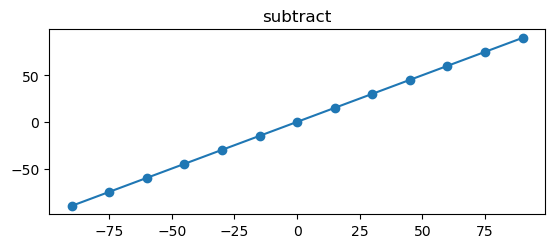

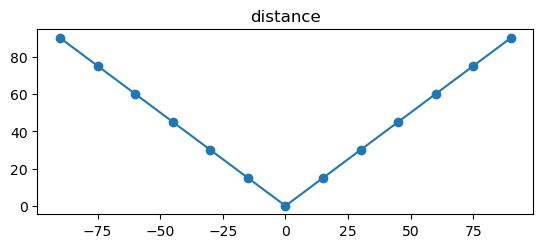

In [2]:
### Parametric tests of circular difference ###
stats = ['subtract','distance']
test_values = iarange(-90,90,15)

for stat in stats:
    diff,_ = test_circ_diff(stat, test_values=test_values, do_tests=False)
    plt.figure()
    ax = plt.subplot(1,1,1)
    plt.plot(test_values, diff.mean(axis=1), 'o-')
    bounds = ax.get_position().bounds # Make plots a bit smaller
    ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])
    plt.title(stat)


All stats unbiased, variance increases with spread, decreases with n


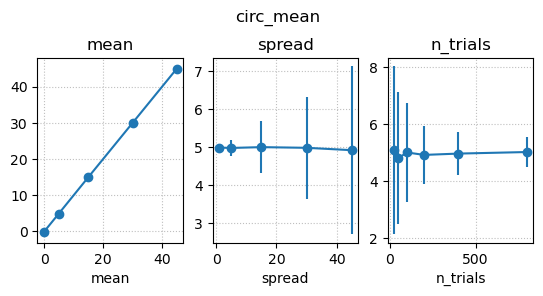

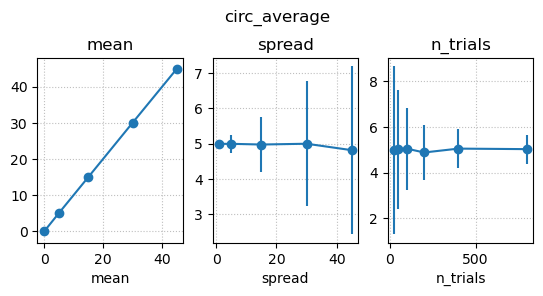

In [3]:
### Parametric tests of circular central tendency ###
stats = ['mean','average']
tests = ['mean','spread','n_trials']

for stat in stats:
    plt.figure()
    n_subplots = (1,3)
    plt.suptitle("circ_%s" % stat)

    for i_test,test in enumerate(tests):
        ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
        means, sds, passed = test_circ_mean(stat=stat, test=test, ax=ax, **extra_args)
        bounds = ax.get_position().bounds # Make plots a bit smaller
        ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])
        plt.title(test)

print("All stats unbiased, variance increases with spread, decreases with n")

All stats increase with spread: STD-FM,dispersion linear, SD-ang dev sublinear, rest supralinear
All stats unbiased by mean, n; variance decrease with n


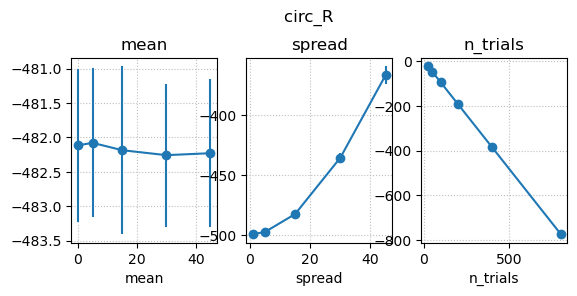

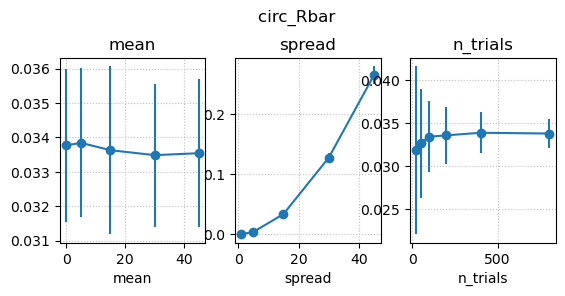

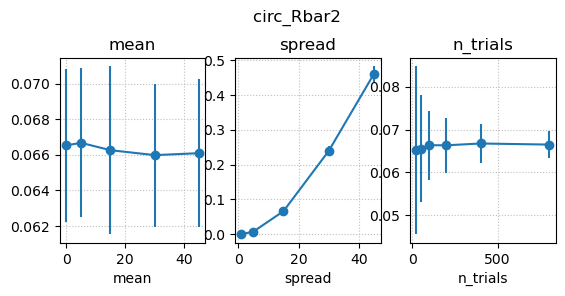

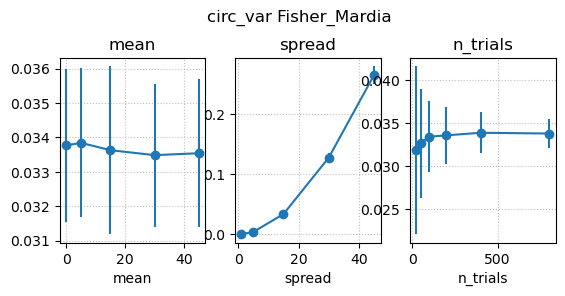

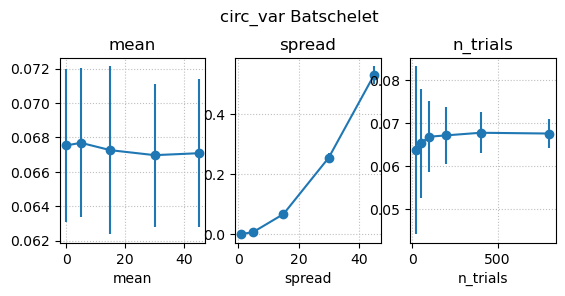

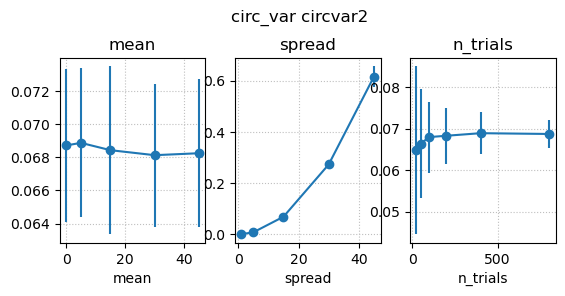

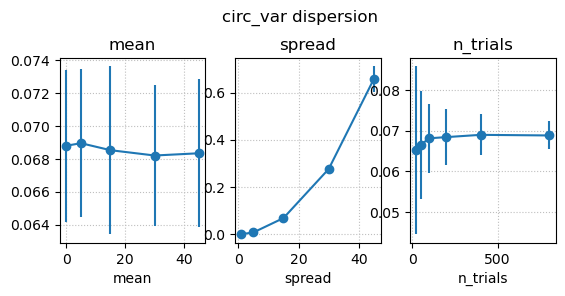

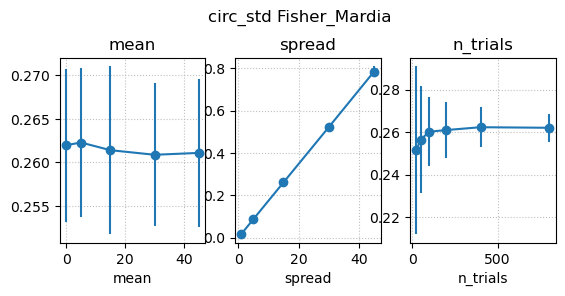

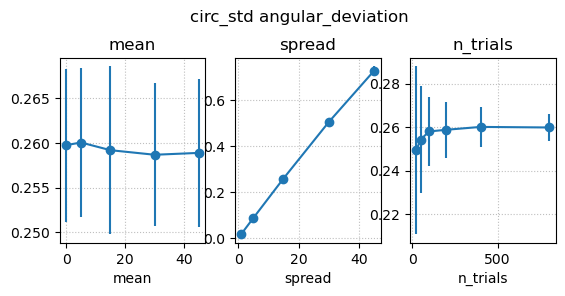

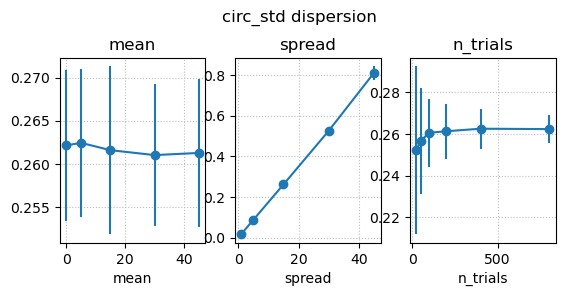

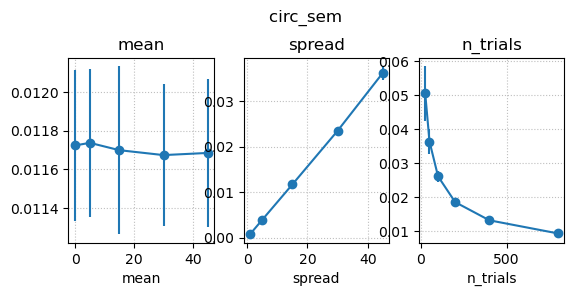

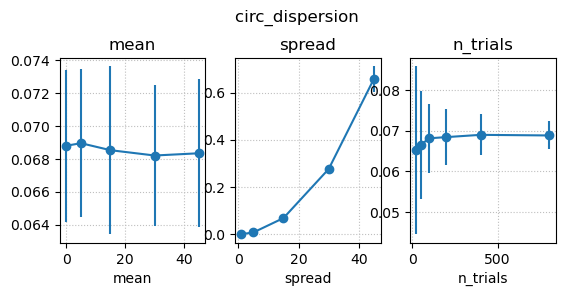

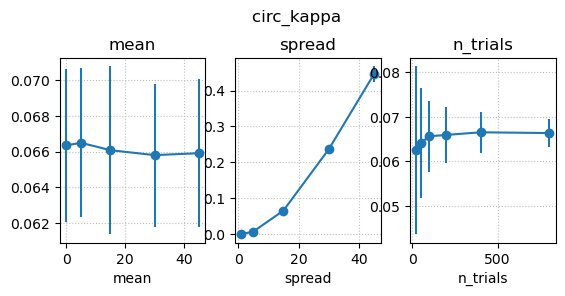

In [4]:
### Parametric tests of measures of circular spread (R/var/SD/dispersion/vonMises kappa) ###
stats = ['R','Rbar','Rbar2','var','std','sem','dispersion','kappa']
tests = ['mean','spread','n_trials']

for stat in stats:
    if stat == 'var':   methods = ['Fisher_Mardia','Batschelet','circvar2','dispersion']
    elif stat == 'std': methods = ['Fisher_Mardia','angular_deviation','dispersion']
    else:               methods = ['']

    for method in methods:
        extra_args_ = extra_args.copy()
        if method != '': extra_args_['method'] = method
        plt.figure()
        n_subplots = (1,3)
        plt.suptitle("circ_%s %s" % (stat,method))

        for i_test,test in enumerate(tests):
            ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
            means, sds, passed = test_circ_spread(stat, test=test, ax=ax, **extra_args_)
            bounds = ax.get_position().bounds # Make plots a bit smaller
            ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])
            plt.title(test)

print("All stats increase with spread: STD-FM,dispersion linear, SD-ang dev sublinear, rest supralinear")
print("All stats unbiased by mean, n; variance decrease with n")

Z increaes, p decreases with spread and n, unbiased by mean angle


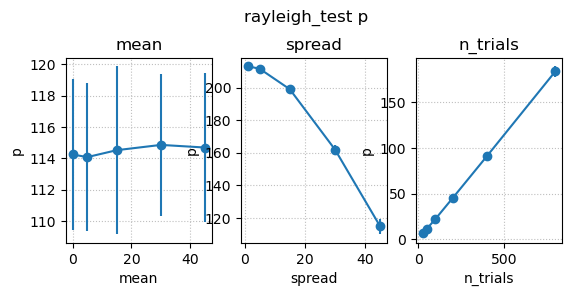

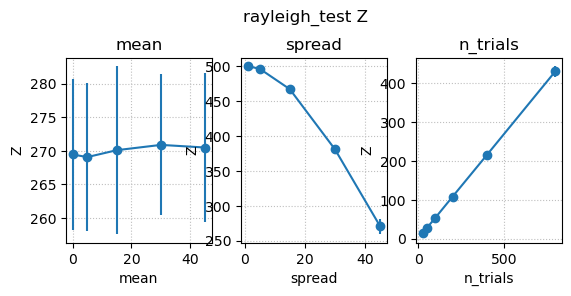

In [5]:
### Parametric tests of rayleigh_test() ###
stats = ['p','Z']
tests = ['mean','spread','n_trials']
for stat in stats:
    plt.figure()
    n_subplots = (1,len(tests))
    plt.suptitle("rayleigh_test %s" % stat)

    for i_test,test in enumerate(tests):
        ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
        means, sds, passed = test_rayleigh_test(test=test, stat=stat, ax=ax, **extra_args)
        plt.title(test)
        bounds = ax.get_position().bounds # Make plots a bit smaller
        ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])

print("Z increaes, p decreases with spread and n, unbiased by mean angle")

/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:720: RuntimeWarning: divide by zero encountered in log10
  values[i_value,i_rep] = -np.log10(p)
/opt/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


S increases, p decreases with SNR and n, unbiased


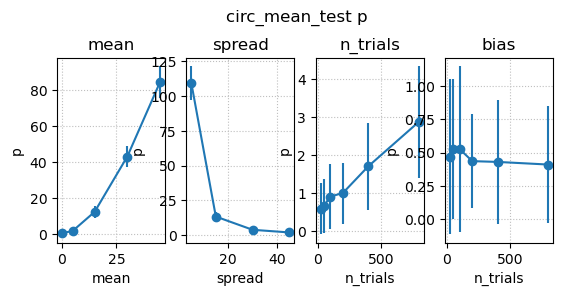

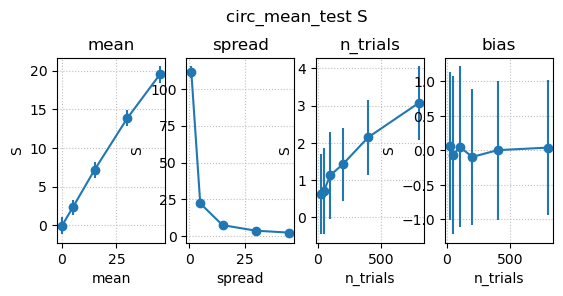

In [6]:
### Parametric tests of circ_mean_test() ###
stats = ['p','S']
tests = ['mean','spread','n_trials','bias']
for stat in stats:
    plt.figure()
    n_subplots = (1,4)
    plt.suptitle("circ_mean_test %s" % stat)

    for i_test,test in enumerate(tests):
        ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
        means, sds, passed = test_circ_mean_test(test=test, stat=stat, ax=ax, **extra_args)
        plt.title(test)
        bounds = ax.get_position().bounds # Make plots a bit smaller
        ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])

print("S increases, p decreases with SNR and n, unbiased")

/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:898: RuntimeWarning: divide by zero encountered in log10
  values[i_value,i_rep] = -np.log10(p)


All stats increase monotonic with gain, n_conds, n_trials(except for pev); decrease monotonic with spread; all unbiased


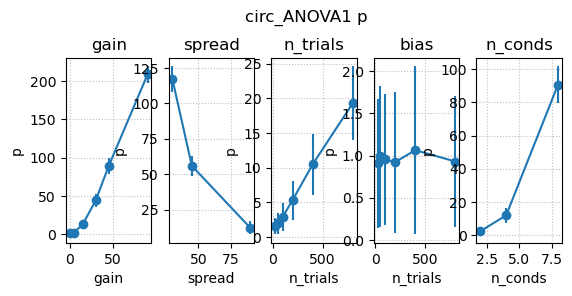

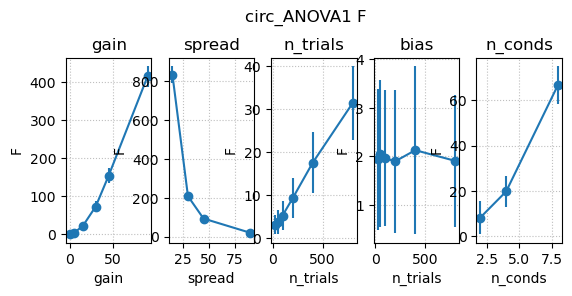

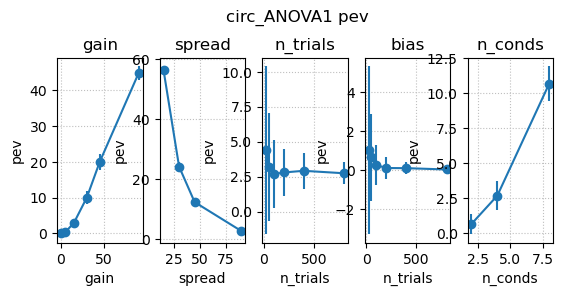

In [7]:
### Parametric tests of circ_ANOVA1() ###
stats = ['p','F','pev']
tests = ['gain','spread','n_trials','bias','n_conds']
for stat in stats:
    plt.figure()
    n_subplots = (1,5)
    plt.suptitle("circ_ANOVA1 %s" % stat)

    for i_test,test in enumerate(tests):
        ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
        means, sds, passed = test_circ_ANOVA1(test=test, stat=stat, ax=ax, **extra_args)
        plt.title(test)
        bounds = ax.get_position().bounds # Make plots a bit smaller
        ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])

print("All stats increase monotonic with gain, n_conds, n_trials(except for pev); decrease monotonic with spread; all unbiased")

/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1139: UserWarning: Stat rho has larger than expected range across spread values
  elif not cond:  warn(message)


Both stats monotonic with correlation; unbiased by slope, mean, mean offset, n; negative bias w/ > spread


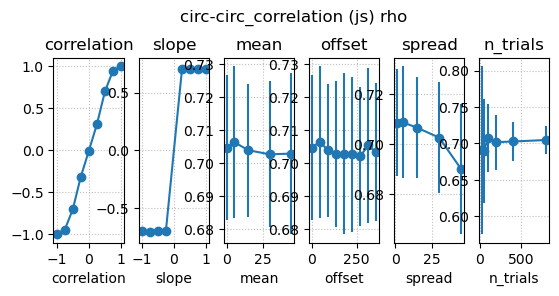

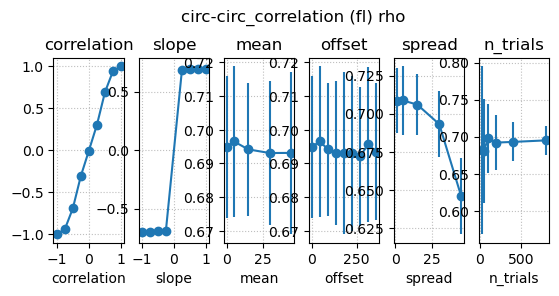

In [8]:
### Parametric tests of circ_circ_correlation() ###
methods = ['js','fl']
tests = ['correlation','slope','mean','offset','spread','n_trials']
stat = 'rho'

for method in methods:
    plt.figure()
    n_subplots = (1,len(tests))
    plt.suptitle("circ-circ_correlation (%s) %s" % (method,stat))

    for i_test,test in enumerate(tests):
        ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
        means, sds, passed = test_circ_correlation(corr_type='circ_circ', method=method, test=test,
                                                   stat=stat, ax=ax, **extra_args)
        plt.title(test)
        bounds = ax.get_position().bounds # Make plots a bit smaller
        ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])

print("Both stats monotonic with correlation; unbiased by slope, mean, mean offset, n; negative bias w/ > spread")

JS: rho is monotonic with correlation; unbiased by mean, mean offset, spread; p inc's w/ n
Mardia: |rho|,|p| are monotonic with correlation; unbiased by mean, mean offset, spread; p inc's w/ n


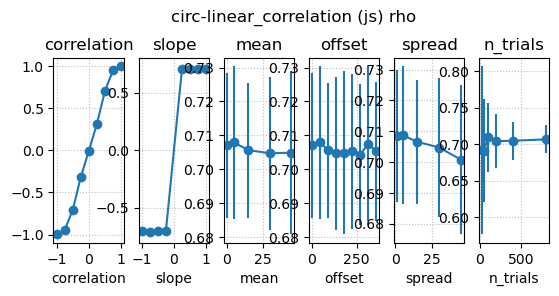

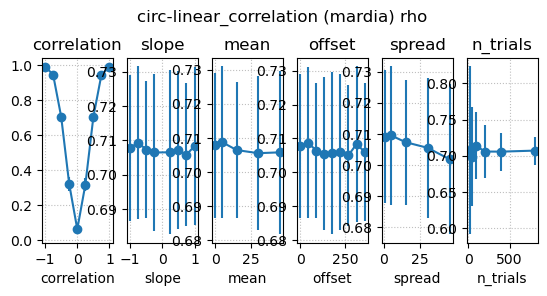

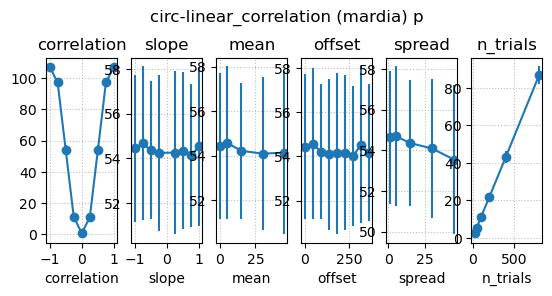

In [11]:
### Parametric tests of circ_linear_correlation() ###
methods = ['js','mardia']
tests = ['correlation','slope','mean','offset','spread','n_trials']
stats = ['rho','p']

for method in methods:
    for stat in stats:
        if (method == 'js') and (stat == 'p'): continue
        plt.figure()
        n_subplots = (1,len(tests))
        plt.suptitle("circ-linear_correlation (%s) %s" % (method,stat))

        for i_test,test in enumerate(tests):
            ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
            means, sds, passed = test_circ_correlation(corr_type='circ_linear', method=method, stat=stat,
                                                       test=test, ax=ax, **extra_args)
            plt.title(test)
            bounds = ax.get_position().bounds # Make plots a bit smaller
            ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])

print("JS: rho is monotonic with correlation; unbiased by mean, mean offset, spread; p inc's w/ n")
print("Mardia: |rho|,|p| are monotonic with correlation; unbiased by mean, mean offset, spread; p inc's w/ n")

/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1320: UserWarning: Stat beta doesn't increase monotonically with simulated correlation
  elif not cond:  warn(message)
/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1320: UserWarning: Stat beta has larger than expected range across spread values
  elif not cond:  warn(message)
/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1320: UserWarning: Stat beta doesn't increase monotonically with simulated slope
  elif not cond:  warn(message)
/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1320: UserWarning: Stat beta doesn't increase monotonically with simulated correlation
  elif not cond:  warn(message)
/Users/sbrincat/Code/Python/spynal/spynal/tests/validity_test_circstats.py:1320: UserWarning: Stat beta has larger than expected range across mean values
  elif not cond:  warn(message)
/Users/sbrincat/Code/Python/spynal/spynal/tests/va

Beta recovers slope, inc's proportional to corr, ~invariant to mean/offset/n
Error dec's proportional to corr, ~invariant to mean/offset/n


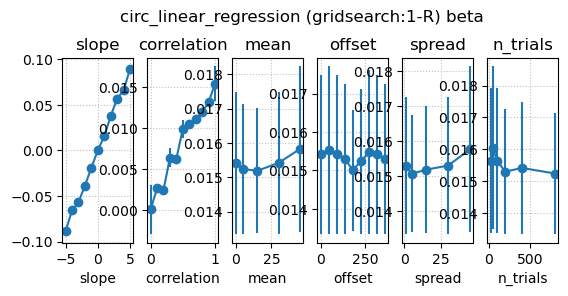

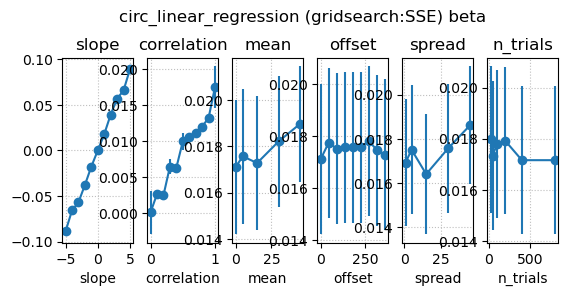

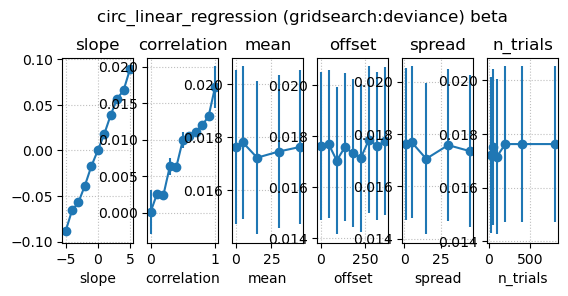

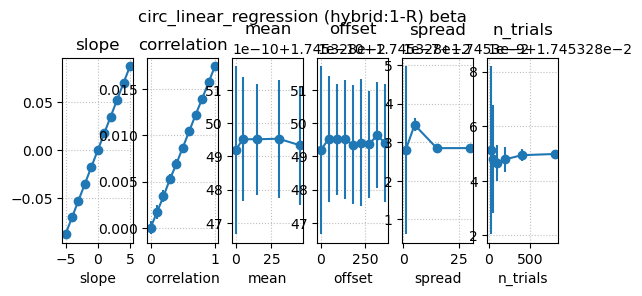

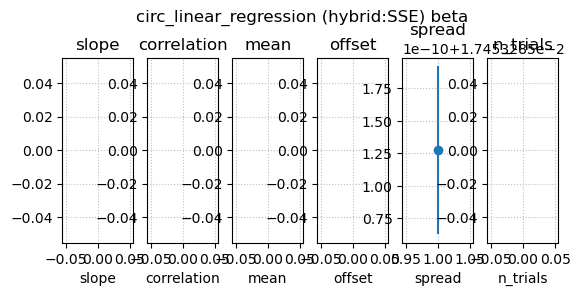

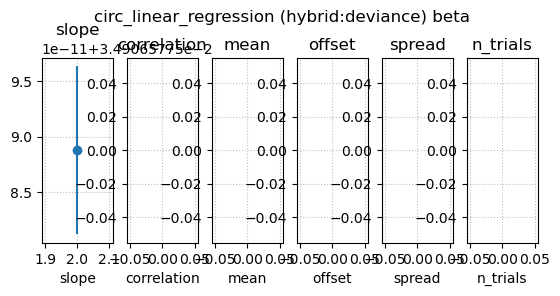

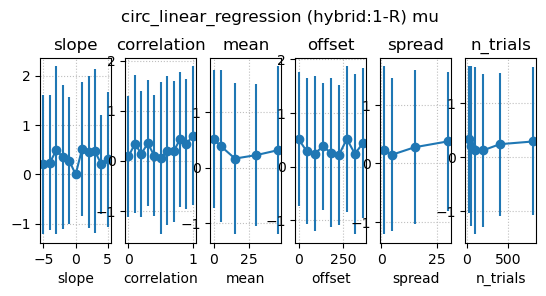

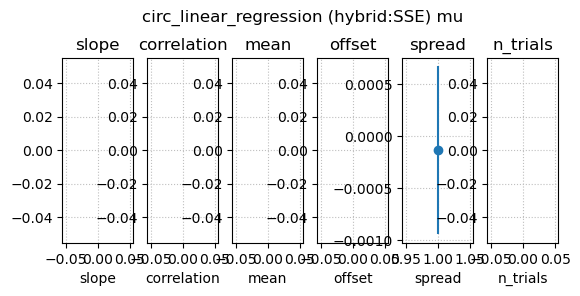

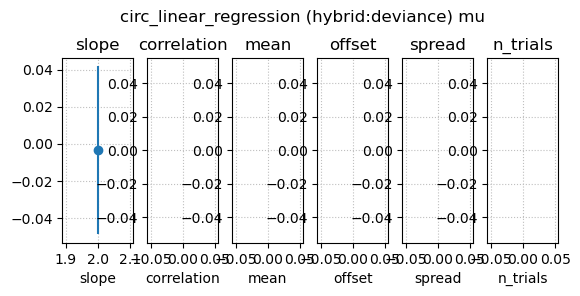

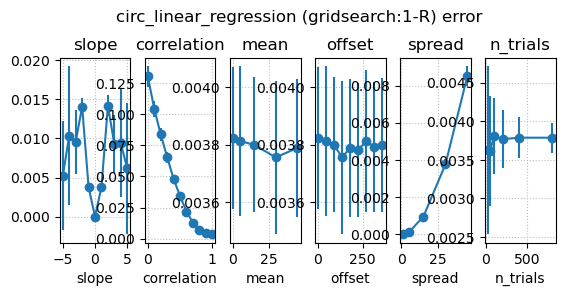

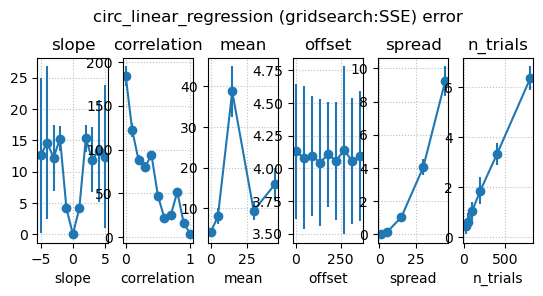

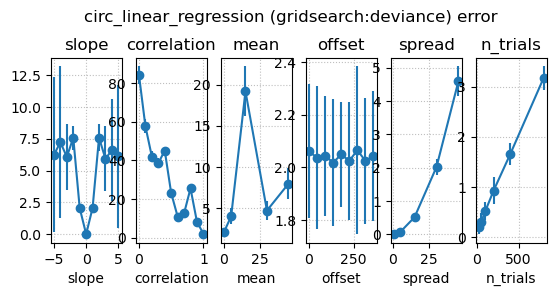

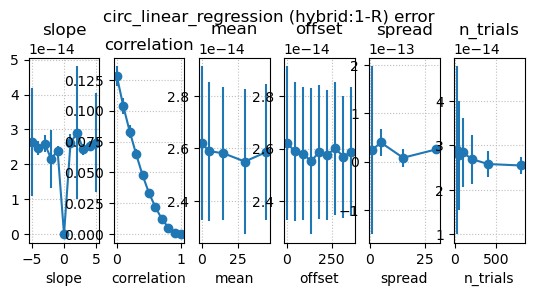

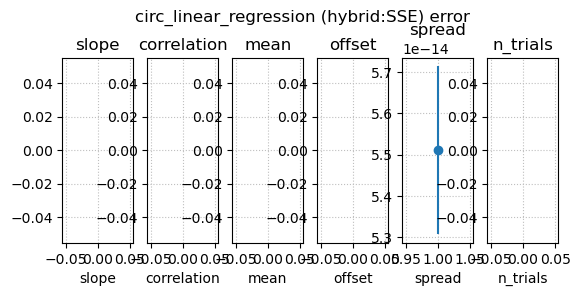

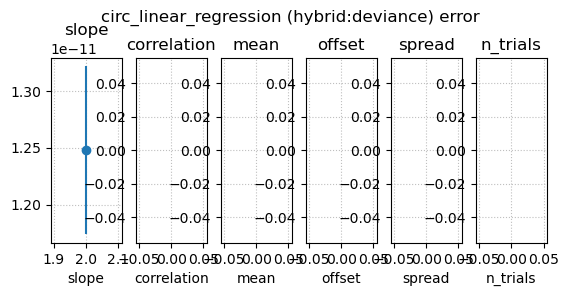

In [10]:
### Parametric tests of circ_linear_regression() ###
tests = ['slope','correlation','mean','offset','spread','n_trials']
errors = ['1-R','SSE','deviance']
fit_methods = ['gridsearch','hybrid']
stats = ['beta','mu','error']

for stat in stats:
    for fit_method in fit_methods:
        for error in errors:
            if (stat == 'mu') and (fit_method == 'gridsearch'): continue
            plt.figure()
            n_subplots = (1,len(tests))
            plt.suptitle("circ_linear_regression (%s:%s) %s" % (fit_method,error,stat))

            for i_test,test in enumerate(tests):
                # print(stat, fit_method, test)
                ax = plt.subplot(n_subplots[0],n_subplots[1],i_test+1)
                means, sds, passed = test_circ_regression(stat=stat, test=test, fit_method=fit_method,
                                                          error=error, ax=ax, **extra_args)
                plt.title(test)
                bounds = ax.get_position().bounds # Make plots a bit smaller
                ax.set_position([bounds[0], bounds[1]+0.5*bounds[3], bounds[2], 0.5*bounds[3]])
                # if (test == 'slope') and (stat == 'beta'): print(means)

print("Beta recovers slope, inc's proportional to corr, ~invariant to mean/offset/n")
print("Error dec's proportional to corr, ~invariant to mean/offset/n")